In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from sotodlib import core
from sotodlib.tod_ops.flags import get_det_bias_flags

from latcom.utils.cut_utils import get_cut_sources, get_det_cal_cuts, get_yield_stages
import latcom.utils.yield_utils as yd
from latcom.utils.optical_loading import (
    aso_tubes,
    lf_tubes,
    ot_from_ufm,
    pwv_interp,
    so_nominal_tubes,
)

%load_ext autoreload
%autoreload 2

# ASO Yields

In [2]:
ctx = core.Context("../../ctxs/smurf_det_preproc.yaml")
ufm = "mv11"
band = "090"
ot = ot_from_ufm(ufm)

start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 6, 30, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)


pwv = pwv_interp()

obs_ctx_list = []
for i, obs in enumerate(obs_list):
    cur_ot = str(obs["obs_id"]).split("_")[2][3:]
    obs_id = str(obs["obs_id"])
    if cur_ot in lf_tubes:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_lf_260604.yaml"))
    else:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_260604.yaml"))

toby_df = yd.aso_toby_df
pton_df = yd.ptown_df

In [3]:
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        ctx = core.Context(ctx_path)
        break
aso_metas = []
for obs_id, ctx_path in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            aso_metas.append(meta)

        except:
            continue

obs_1780272171_lati6_111
obs_1780272171_lati6_111


/global/u2/j/jorlo/dev/sotodlib/sotodlib/core/metadata/loader.py:996: MetadataSpecWarning: metadata spec contains 'unpack' and 'name' entries; ignoring the latter (except to set the 'label', maybe).
  warnings.warn(


obs_1780277754_lati6_111
obs_1780280083_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/users/mmccrack/so/det_match/lat/260204_aso/aso/focal_planes_260517/results//assignment.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780283695_lati6_110', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/users/mmccrack/so/det_match/lat/260204_aso/aso/focal_planes_260517/results//assignment.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780288319_lati6_110', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f090'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/users/mmccrack/so/det_match/lat/260204_aso/aso/focal_pla

obs_1780283695_lati6_110
obs_1780288319_lati6_110
obs_1780292197_lati6_110
obs_1780294593_lati6_110


...

obs_1782137167_lati6_111
obs_1782138844_lati6_111
obs_1782145962_lati6_111
obs_1782148394_lati6_111
obs_1782151857_lati6_111
obs_1782156497_lati6_111
obs_1782159091_lati6_111
obs_1782162691_lati6_111
obs_1782166296_lati6_111
obs_1782169883_lati6_111
obs_1782175425_lati6_111
obs_1782176624_lati6_111
obs_1782180254_lati6_111
obs_1782184175_lati6_111
obs_1782187609_lati6_111
obs_1782192232_lati6_111
obs_1782194824_lati6_111
obs_1782198428_lati6_111
obs_1782202027_lati6_111
obs_1782209156_lati6_111
obs_1782212859_lati6_111
obs_1782223348_lati6_111
obs_1782224588_lati6_111
obs_1782231185_lati6_111
obs_1782247375_lati6_111
obs_1782248589_lati6_111
obs_1782256316_lati6_111
obs_1782261047_lati6_111
obs_1782262618_lati6_111
obs_1782268140_lati6_111
obs_1782269828_lati6_111
obs_1782271238_lati6_111
obs_1782273463_lati6_111
obs_1782277066_lati6_111
obs_1782280666_lati6_111
obs_1782285285_lati6_111
obs_1782287849_lati6_111
obs_1782291455_lati6_111
obs_1782295059_lati6_111
obs_1782298670_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1782329309_lati6_111', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f090'}




obs_1782333993_lati6_111
obs_1782337618_lati6_111
obs_1782345950_lati6_111
obs_1782349357_lati6_111
obs_1782352959_lati6_111
obs_1782357410_lati6_111
obs_1782360940_lati6_111
obs_1782363508_lati6_111
obs_1782367117_lati6_111
obs_1782370726_lati6_111
obs_1782374329_lati6_111
obs_1782378941_lati6_111
obs_1782381507_lati6_111
obs_1782385114_lati6_111
obs_1782388715_lati6_111
obs_1782392320_lati6_111
obs_1782396940_lati6_111
obs_1782435167_lati6_111
obs_1782436770_lati6_111
obs_1782440370_lati6_111
obs_1782443690_lati6_111
obs_1782445873_lati6_111
obs_1782450513_lati6_111
obs_1782453104_lati6_111
obs_1782456706_lati6_111
obs_1782460308_lati6_111
obs_1782463909_lati6_111
obs_1782468514_lati6_111
obs_1782471100_lati6_111
obs_1782474733_lati6_111
obs_1782475899_lati6_111
obs_1782478571_lati6_111
obs_1782483190_lati6_111
obs_1782485779_lati6_111
obs_1782490170_lati6_111
obs_1782493989_lati6_111
obs_1782496177_lati6_111
obs_1782500813_lati6_111
obs_1782503406_lati6_111
obs_1782507007_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1782702211_lati6_111', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f090'}




obs_1782703132_lati6_111
obs_1782707192_lati6_111
obs_1782709793_lati6_111
obs_1782713392_lati6_111
obs_1782716993_lati6_111
obs_1782720592_lati6_111
obs_1782725193_lati6_111
obs_1782727790_lati6_111
obs_1782731393_lati6_111
obs_1782734993_lati6_111
obs_1782738598_lati6_111
obs_1782743192_lati6_111
obs_1782751538_lati6_111
obs_1782756095_lati6_111
obs_1782760564_lati6_111
obs_1782763220_lati6_111
obs_1782768790_lati6_111
obs_1782771447_lati6_111
obs_1782774049_lati6_111


In [4]:
obs_ids = []
times = []
naive_yields = []
noise_yields = []
n_cuts = []
cut_names = []
pwvs = []

for i in range(len(aso_metas)):
    meta = aso_metas[i]
    obs_id = meta.obs_info.obs_id

    ndet, stage_name = get_yield_stages(meta=meta, ufm=ufm, band=band)
    naive_yield = ndet[0] / 860

    print(
        "Number of dets after get_bias_flags: ",
        naive_yield * 860,
        " current yield ",
        naive_yield,
    )
    noise_yield = ndet[-1] / 860
    noise_yields.append(noise_yield)

    n_cut, cut_name = -1*np.diff(ndet), stage_name[1:]
    n_cuts.append(n_cut)
    cut_names.append(cut_name)
    obs_ids.append(obs_id.split("_")[1])
    times.append(dt.datetime.fromtimestamp(int(obs_id.split("_")[1])))
    naive_yields.append(naive_yield)

    print(
        "Number of dets with noise estimate: ",
        noise_yield * 860,
        " current yield ",
        noise_yield,
    )
    pwvs.append(pwv(obs_id.split("_")[1]))

Number of dets after get_bias_flags:  807.0  current yield  0.9383720930232559
Number of dets with noise estimate:  161.0  current yield  0.1872093023255814
Number of dets after get_bias_flags:  807.0  current yield  0.9383720930232559
Number of dets with noise estimate:  162.0  current yield  0.1883720930232558
Number of dets after get_bias_flags:  807.0  current yield  0.9383720930232559
Number of dets with noise estimate:  162.0  current yield  0.1883720930232558
Number of dets after get_bias_flags:  807.0  current yield  0.9383720930232559
Number of dets with noise estimate:  487.00000000000006  current yield  0.5662790697674419
Number of dets after get_bias_flags:  807.0  current yield  0.9383720930232559
Number of dets with noise estimate:  430.0  current yield  0.5
Number of dets after get_bias_flags:  807.0  current yield  0.9383720930232559
Number of dets with noise estimate:  470.0  current yield  0.5465116279069767
Number of dets after get_bias_flags:  807.0  current yield  

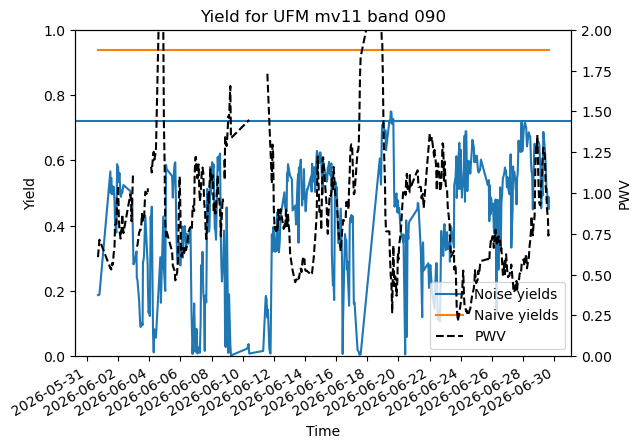

In [5]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()
noise = ax.plot(times, noise_yields, label="Noise yields")
bias = ax.plot(times, naive_yields, label="Naive yields")

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

ax.axhline(
    pton_df.loc[pton_df.labels == f"{band}_{ufm}", "yields"].to_numpy(), label="PTon"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = noise + bias + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"yield_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"yield_{ufm}_{band}.png", dpi=600)

plt.show()

In [6]:
cuts = cut_names[0]
for i in range(len(cut_names)):
    if i == 0:
        cut_dict = {}
        for name in cuts:
            cut_dict[name] = []
    for j, name in enumerate(cuts):
        cut_dict[name].append(n_cuts[i][j])

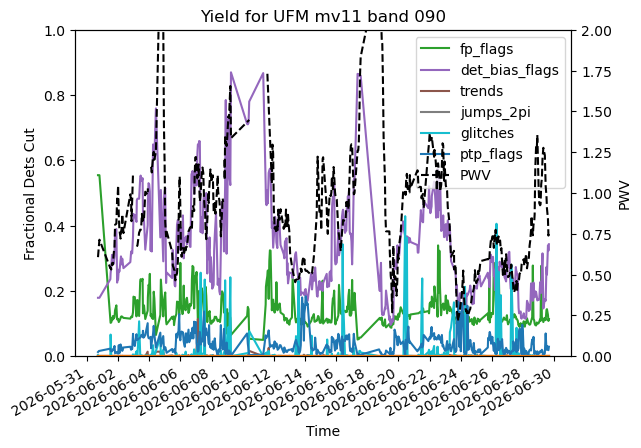

In [7]:
fig, ax = plt.subplots()
lns = []
for cut, n_cut in cut_dict.items():
    cur_ln = ax.plot(times, np.array(n_cut) / 860, label=cut)
    if np.amax(n_cut)>10 and cut !="source_flags":
        lns += cur_ln

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Fractional Dets Cut")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = lns+ pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Cuts for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"cuts_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"cuts_{ufm}_{band}.png", dpi=600)

plt.show()

# SO Nominal Yields

In [7]:
ctx = core.Context("../../ctxs/smurf_det_preproc.yaml")
ufm = "mv11"
band = "090"
ot = ot_from_ufm(ufm)

start = dt.datetime(2025, 10, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2025, 10, 2, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

pwv = pwv_interp()

obs_ids_list = []
for i, obs in enumerate(obs_list):
    obs_ids_list.append(str(obs["obs_id"]))

In [5]:
old_ctx = core.Context("../../ctxs/old_smurf_det_preproc.yaml")
nominal_metas = []
for obs_id in obs_ids_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = old_ctx.get_meta(
                obs_id,
                dets={
                    "dets:stream_id": "ufm_" + str(ufm),
                    "dets:wafer.bandpass": "f" + str(band),
                },
            )
            nominal_metas.append(meta)

        except:
            continue

obs_1759277302_lati6_111
obs_1759279464_lati6_111
obs_1759283073_lati6_111
obs_1759286666_lati6_111
obs_1759291137_lati6_111
obs_1759293425_lati6_111
obs_1759297032_lati6_111
obs_1759300625_lati6_111
obs_1759304236_lati6_111
obs_1759307677_lati6_101
obs_1759309851_lati6_111
obs_1759313441_lati6_111
obs_1759319129_lati6_111
obs_1759321579_lati6_111
obs_1759325199_lati6_111
obs_1759332340_lati6_111
obs_1759337248_lati6_111
obs_1759339808_lati6_111
obs_1759352276_lati6_111
obs_1759354024_lati6_111
obs_1759357614_lati6_111


In [11]:
obs_ids = []
times = []
naive_yields = []
noise_yields = []
n_cuts = []
cut_names = []
pwvs = []

for i in range(len(nominal_metas)):
    meta = nominal_metas[i]
    obs_id = meta.obs_info.obs_id

    ndet, stage_name = get_yield_stages(meta=meta, ufm=ufm, band=band)
    naive_yield = ndet[0] / 860

    print(
        "Number of dets after get_bias_flags: ",
        naive_yield * 860,
        " current yield ",
        naive_yield,
    )
    noise_yield = ndet[-1] / 860
    noise_yields.append(noise_yield)

    n_cut, cut_name = -1*np.diff(ndet), stage_name[1:]
    n_cuts.append(n_cut)
    cut_names.append(cut_name)
    obs_ids.append(obs_id.split("_")[1])
    times.append(dt.datetime.fromtimestamp(int(obs_id.split("_")[1])))
    naive_yields.append(naive_yield)

    print(
        "Number of dets with noise estimate: ",
        noise_yield * 860,
        " current yield ",
        noise_yield,
    )
    pwvs.append(pwv(obs_id.split("_")[1]))

Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  377.0  current yield  0.4383720930232558
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  376.0  current yield  0.4372093023255814
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  378.0  current yield  0.43953488372093025
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  378.0  current yield  0.43953488372093025
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  388.0  current yield  0.4511627906976744
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  388.0  current yield  0.4511627906976744
Number of dets after get_bias_flags:  0.0  current yield  0.0
Number of dets with noise estimate:  387.0  current yield  0.45
Number of dets after get_bias_fl

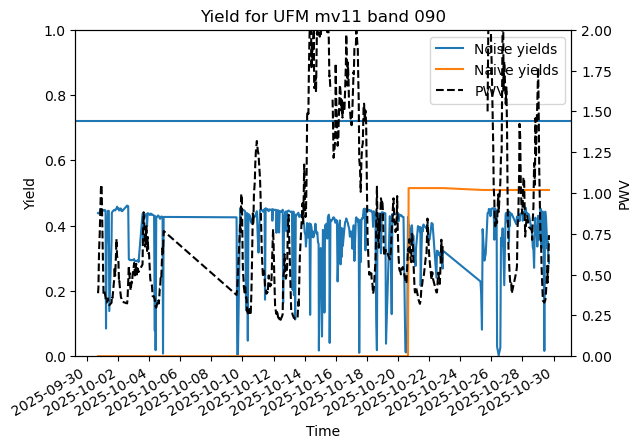

In [15]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()
noise = ax.plot(times, noise_yields, label="Noise yields")
bias = ax.plot(times, naive_yields, label="Naive yields")

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

ax.axhline(
    pton_df.loc[pton_df.labels == f"{band}_{ufm}", "yields"].to_numpy(), label="PTon"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = noise + bias + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"old_yield_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"old_yield_{ufm}_{band}.png", dpi=600)

plt.show()

In [16]:
cuts = cut_names[0]
for i in range(len(cut_names)):
    if i == 0:
        cut_dict = {}
        for name in cuts:
            cut_dict[name] = []
    for j, name in enumerate(cuts):
        cut_dict[name].append(n_cuts[i][j])


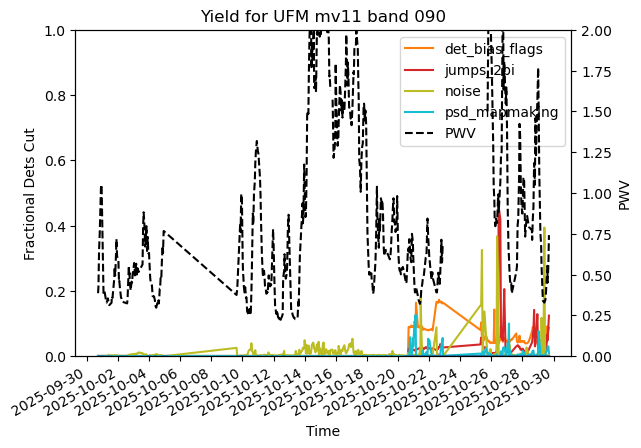

In [17]:
fig, ax = plt.subplots()
lns = []
for cut, n_cut in cut_dict.items():
    cur_ln = ax.plot(times, np.array(n_cut) / 860, label=cut)
    if np.amax(n_cut)>30 and cut !="source_flags":
        lns += cur_ln

ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Fractional Dets Cut")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = lns+ pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"old_cuts_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"old_cuts_{ufm}_{band}.png", dpi=600)

plt.show()